In [35]:
import pandas as pd
data=pd.read_csv("titanic.csv")

X = data[['pclass', 'sex', 'age', 'fare']]
y = data['survived']

X['age'] = X['age'].fillna(X['age'].mean())
X['sex'] = X['sex'].map({'male': 0, 'female': 1})

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)



In [44]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7574626865671642


In [46]:
print("Train Score:", tree.score(X_train, y_train))
print("Test Score :", tree.score(X_test, y_test))

Train Score: 0.9791332263242376
Test Score : 0.7574626865671642


In [55]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
tree.fit(X_train,y_train)
print("train",tree.score(X_train,y_train))
print("test",tree.score(X_test,y_test))

train 0.826645264847512
test 0.8059701492537313


In [57]:
print(X.columns)
print(tree.feature_importances_)


Index(['pclass', 'sex', 'age', 'fare'], dtype='str')
[0.18659407 0.60754695 0.08850985 0.11734913]


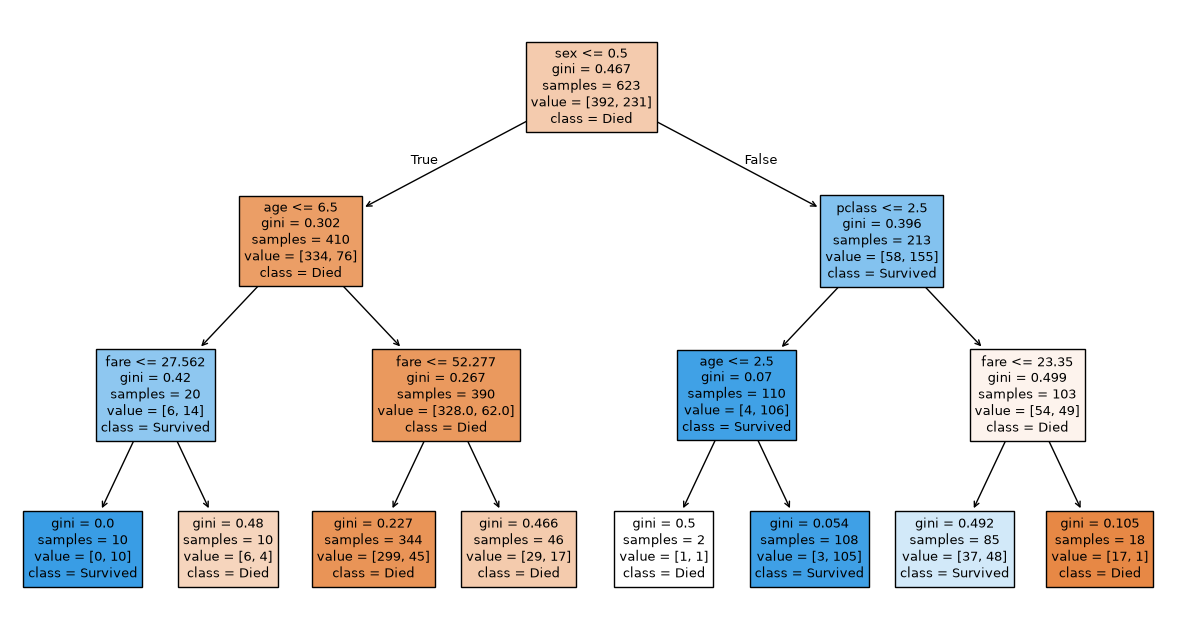

In [58]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['Died','Survived'],
    filled=True
)

plt.show()